# Amazon Stock Agent — Demo Execution

This notebook demonstrates the full end-to-end flow of the Stock Query Agent:
1. Authenticate via Cognito
2. Run 5 different queries (real-time, historical, RAG, combined)
3. Capture Langfuse trace IDs for observability

## Prerequisites

**Option A — Local (docker-compose):**
```bash
cp .env.example .env   # fill in your values
docker compose up --build
```

**Option B — AWS (Terraform):**
```bash
cd terraform/
cp terraform.tfvars.example terraform.tfvars  # edit values
terraform init && terraform apply
```

Then create a test user in Cognito:
```bash
aws cognito-idp admin-create-user \
  --user-pool-id <POOL_ID> \
  --username testuser@example.com \
  --user-attributes Name=email,Value=testuser@example.com Name=name,Value=TestUser \
  --temporary-password 'TempPass123!'
```

---
## 1. Setup

In [1]:
import json
import os
import time
from datetime import datetime, timezone

import httpx
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

# ── Configuration ─────────────────────────────────────────────────
BASE_URL = os.getenv("API_URL", "http://localhost:8000")
USERNAME = os.getenv("TEST_USERNAME", "testuser@example.com")
PASSWORD = os.getenv("TEST_PASSWORD", "TestPass123\\!")

# Will be populated after auth
access_token = None
headers = {}

# Track execution times and trace IDs
results_log = []

print(f"API endpoint: {BASE_URL}")
print(f"Test user:    {USERNAME}")

API endpoint: http://localhost:8000
Test user:    testuser@example.com


In [2]:
# Helper: send a streaming query and collect results
async def stream_query(question: str, label: str) -> dict:
    """Send a streaming POST /query request and print events in real time."""
    start = time.time()
    events = []
    trace_id = None
    final_answer = ""

    print(f"\n{'='*60}")
    print(f"Query: {question}")
    print(f"{'='*60}")

    async with httpx.AsyncClient(timeout=120.0) as client:
        async with client.stream(
            "POST",
            f"{BASE_URL}/query",
            headers=headers,
            json={"query": question, "stream": True},
        ) as resp:
            async for line in resp.aiter_lines():
                if not line.startswith("data: "):
                    continue
                event = json.loads(line[6:])
                events.append(event)
                trace_id = event.get("trace_id", trace_id)

                etype = event["type"]
                content = event.get("content", "")

                if etype == "thought":
                    print(f"  [Thought]  {content[:120]}")
                elif etype == "action":
                    print(f"  [Action]   {content}")
                elif etype == "observation":
                    print(f"  [Observe]  {content[:150]}...")
                elif etype == "final_answer":
                    final_answer = content
                    print(f"  [Answer]   {content[:200]}")
                elif etype == "done":
                    print("  [Done]")

    elapsed = round(time.time() - start, 2)
    result = {
        "label": label,
        "question": question,
        "trace_id": trace_id,
        "elapsed_s": elapsed,
        "events": events,
        "answer": final_answer,
    }
    results_log.append(result)
    print(f"\n  Trace ID: {trace_id}")
    print(f"  Time:     {elapsed}s")
    return result


# Helper: non-streaming query
async def simple_query(question: str, label: str) -> dict:
    """Send a non-streaming POST /query request."""
    start = time.time()
    async with httpx.AsyncClient(timeout=120.0) as client:
        r = await client.post(
            f"{BASE_URL}/query",
            headers=headers,
            json={"query": question, "stream": False},
        )
        data = r.json()

    elapsed = round(time.time() - start, 2)
    result = {
        "label": label,
        "question": question,
        "trace_id": data.get("trace_id"),
        "elapsed_s": elapsed,
        "answer": data.get("answer", ""),
        "sources": data.get("sources", []),
    }
    results_log.append(result)
    return result

---
## 2. Health Check & Authentication

In [3]:
# Health check
async with httpx.AsyncClient() as client:
    r = await client.get(f"{BASE_URL}/health")
    health = r.json()
    print("Health:", health)
    assert health["status"] == "healthy", "API is not healthy!"

Health: {'status': 'healthy', 'environment': 'development', 'timestamp': '2026-03-04T20:31:44.805227+00:00'}


In [4]:
# Authenticate with Cognito
async with httpx.AsyncClient() as client:
    r = await client.post(
        f"{BASE_URL}/auth/token",
        json={"username": USERNAME, "password": PASSWORD},
    )
    assert r.status_code == 200, f"Auth failed: {r.text}"
    tokens = r.json()
    access_token = tokens["access_token"]
    headers = {"Authorization": f"Bearer {access_token}"}

print("Authenticated successfully.")
print(f"Token type:  {tokens['token_type']}")
print(f"Expires in:  {tokens['expires_in']}s")

Authenticated successfully.
Token type:  Bearer
Expires in:  3600s


In [5]:
# Verify user profile
async with httpx.AsyncClient() as client:
    r = await client.get(f"{BASE_URL}/auth/user", headers=headers)
    user_info = r.json()
    print("User info:")
    for k, v in user_info.items():
        print(f"  {k}: {v}")

User info:
  username: c11b65b0-50d1-705a-3716-ccbfce773a2b
  email: testuser@example.com
  name: Test User
  email_verified: False
  sub: c11b65b0-50d1-705a-3716-ccbfce773a2b


---
## 3. Query Executions

### 3a. Real-time stock price

In [6]:
result_a = await stream_query(
    "What is the stock price for Amazon right now?",
    label="3a_realtime_price",
)


Query: What is the stock price for Amazon right now?


  [Thought]  [{'type': 'text', 'text': "I'll get the current stock price for Amazon (AMZN) for you."}, {'type': 'tool_use', 'name': 'retrieve_realtime_stock_price', 'input': {'ticker': 'AMZN'}, 'id': 'tooluse_6r9xM6pgFMq1pdeHKOzbM3'}]
  [Action]   {"tool": "retrieve_realtime_stock_price", "args": {"ticker": "AMZN"}}


  [Observe]  {"ticker": "AMZN", "price": 216.73, "currency": "USD", "timestamp": "2026-03-04T20:31:49.862812+00:00", "change_percent": 3.83}...


  [Answer]   Amazon (AMZN) is currently trading at **$216.73 USD**.

Key details:
- **Current Price**: $216.73
- **Daily Change**: +3.83% (up from previous close)
- **Currency**: USD
- **Last Updated**: March 4, 2


  [Done]

  Trace ID: b38a0c88-c835-44f3-a5d6-ec834b9e3f2b
  Time:     7.76s


In [7]:
display(Markdown(f"### Agent Answer\n\n{result_a['answer']}"))

### Agent Answer

Amazon (AMZN) is currently trading at **$216.73 USD**.

Key details:
- **Current Price**: $216.73
- **Daily Change**: +3.83% (up from previous close)
- **Currency**: USD
- **Last Updated**: March 4, 2026 at 8:31 PM UTC

Amazon's stock is having a strong day with a gain of nearly 4%, indicating positive market sentiment. This represents a solid upward movement from the previous trading session.

#### Langfuse Trace — 3a. Real-time stock price

![Langfuse trace for real-time stock price query](3a.png)

### 3b. Historical stock prices (Q4 2024)

In [8]:
result_b = await stream_query(
    "What were the stock prices for Amazon in Q4 last year?",
    label="3b_historical_q4",
)


Query: What were the stock prices for Amazon in Q4 last year?


  [Thought]  [{'type': 'text', 'text': "I'll retrieve Amazon's historical stock prices for Q4 2023 (October-December). Let me get that data for you."}, {'type': 'tool_use', 'name': 'retrieve_historical_stock_price', 'input': {'ticker': 'AMZN', 'start_date': '2023-10-01', 'end_date': '2023-12-31'}, 'id': 'tooluse_i8BBmqhsVgRTjQfAChI6R6'}]
  [Action]   {"tool": "retrieve_historical_stock_price", "args": {"ticker": "AMZN", "start_date": "2023-10-01", "end_date": "2023-12-31"}}
  [Observe]  {"ticker": "AMZN", "start_date": "2023-10-01", "end_date": "2023-12-31", "prices": [{"date": "2023-10-02", "open": 127.28, "close": 129.46, "high": 13...


  [Answer]   Based on the historical data for Amazon (AMZN) during Q4 2023, here's a comprehensive analysis:

## Amazon Stock Performance in Q4 2023

**Overall Trend:** Strong upward momentum (+17.4% for the quart


  [Done]

  Trace ID: c1a95e0a-bbdb-4f2a-8a21-41a347a3fcc2
  Time:     13.18s


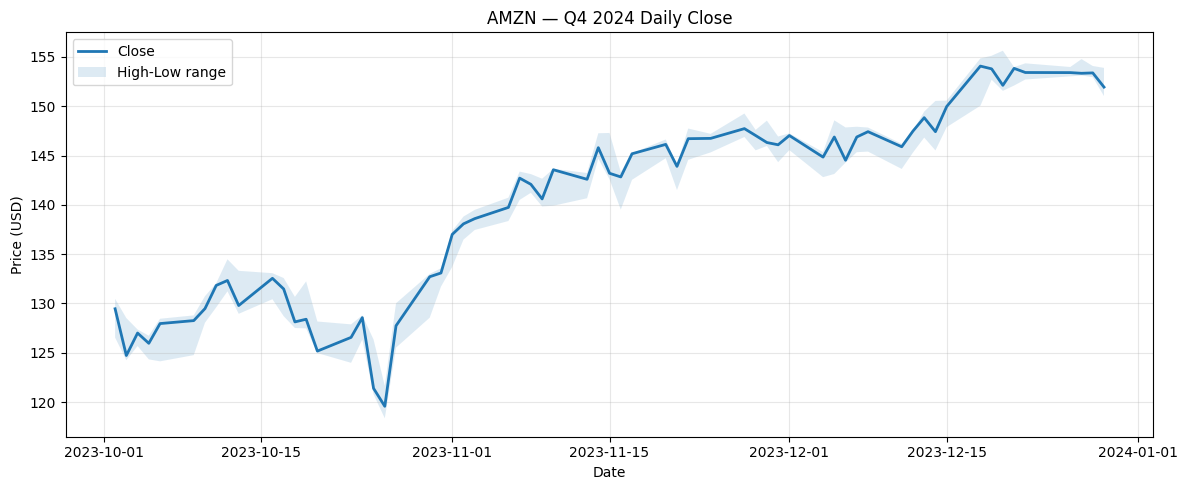

### Agent Answer

Based on the historical data for Amazon (AMZN) during Q4 2023, here's a comprehensive analysis:

## Amazon Stock Performance in Q4 2023

**Overall Trend:** Strong upward momentum (+17.4% for the quarter)
- **Starting Price (Oct 2):** $129.46
- **Ending Price (Dec 29):** $151.94
- **Average Price:** $140.18

### Key Highlights by Month:

**October 2023:**
- Started at $129.46, experienced volatility mid-month
- Notable dip to $119.57 on Oct 26 (likely earnings-related)
- Strong recovery by month-end to $133.09

**November 2023:**
- Consistent upward trend throughout the month
- Peaked at $147.73 on Nov 27
- Range: $133.09 - $147.73 (+11% monthly gain)

**December 2023:**
- Continued strength with further gains
- Reached quarterly high of $155.63 on Dec 20
- Finished strong at $151.94

### Notable Observations:
1. **Volatility Spike:** Oct 25-27 saw significant volatility (likely around earnings announcement)
2. **Holiday Rally:** Strong performance through November and December
3. **Volume Patterns:** Higher trading volumes during earnings periods and year-end
4. **Resistance Levels:** Stock found support around $145-150 range in December

The Q4 2023 performance shows Amazon had a very strong quarter, with the stock gaining substantial value and demonstrating resilience after initial earnings volatility in October.

In [9]:
# Plot historical prices if observation data is available
price_data = None
for ev in result_b.get("events", []):
    if ev["type"] == "observation":
        try:
            parsed = json.loads(ev["content"])
            if "prices" in parsed:
                price_data = parsed["prices"]
        except (json.JSONDecodeError, TypeError):
            pass

if price_data:
    df = pd.DataFrame(price_data)
    df["date"] = pd.to_datetime(df["date"])
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df["date"], df["close"], label="Close", linewidth=2)
    ax.fill_between(df["date"], df["low"], df["high"], alpha=0.15, label="High-Low range")
    ax.set_title("AMZN — Q4 2024 Daily Close")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No structured price data found in observations.")

display(Markdown(f"### Agent Answer\n\n{result_b['answer']}"))

#### Langfuse Trace — 3b. Historical stock prices

![Langfuse trace for historical stock prices query](3b.png)

### 3c. Combined: stock performance vs analyst reports

In [10]:
result_c = await stream_query(
    "Compare Amazon's recent stock performance to what analysts predicted in their reports",
    label="3c_compare_reports",
)


Query: Compare Amazon's recent stock performance to what analysts predicted in their reports


  [Thought]  [{'type': 'text', 'text': "I'll help you compare Amazon's recent stock performance with analyst predictions. Let me gather both the current stock data and search for analyst reports."}, {'type': 'tool_use', 'name': 'retrieve_realtime_stock_price', 'input': {'ticker': 'AMZN'}, 'id': 'tooluse_D6KU8rEZOAGexSZ1zvE2Wu'}, {'type': 'tool_use', 'name': 'retrieve_historical_stock_price', 'input': {'ticker': 'AMZN', 'start_date': '2024-01-01', 'end_date': '2024-12-19'}, 'id': 'tooluse_m2br9wZV8gZpqI8feldL1d'}, {'type': 'tool_use', 'name': 'search_financial_documents', 'input': {'query': 'Amazon analyst predictions price target forecast 2024'}, 'id': 'tooluse_XGehQPORsfxCYrkLj4DCfg'}]
  [Action]   {"tool": "retrieve_realtime_stock_price", "args": {"ticker": "AMZN"}}
  [Thought]  [{'type': 'text', 'text': "I'll help you compare Amazon's recent stock performance with analyst predictions. Let me gather both the current stock data and search for analyst reports."}, {'type': 'tool_use', '

  [Observe]  {"ticker": "AMZN", "price": 216.72, "currency": "USD", "timestamp": "2026-03-04T20:32:13.186479+00:00", "change_percent": 3.83}...
  [Observe]  {"ticker": "AMZN", "start_date": "2024-01-01", "end_date": "2024-12-19", "prices": [{"date": "2024-01-02", "open": 151.54, "close": 149.93, "high": 15...
  [Observe]  ["Road House, The Idea of You,and Red One, live sports likeThursday Night Footballand UEFA Champions\nLeague in Europe (with the NBA and NASCAR coming...


  [Answer]   Based on the data I've gathered, here's a comprehensive comparison of Amazon's recent stock performance versus analyst predictions:

## Current Stock Performance (2024)

**Amazon (AMZN) Current Status


  [Done]

  Trace ID: fae768a0-b9a8-4ff6-bfea-d7d696cd96f7
  Time:     19.19s


In [11]:
display(Markdown(f"### Agent Answer\n\n{result_c['answer']}"))

### Agent Answer

Based on the data I've gathered, here's a comprehensive comparison of Amazon's recent stock performance versus analyst predictions:

## Current Stock Performance (2024)

**Amazon (AMZN) Current Status:**
- **Current Price:** $216.72 (up 3.83% today)
- **2024 Performance:** Strong upward trend from $149.93 (Jan 2) to $220.52 (Dec 18)
- **Year-to-Date Gain:** Approximately 47% increase
- **Average Price in 2024:** $183.33

## Key Performance Highlights

**Stock Price Journey in 2024:**
- Started the year around $150
- Experienced significant volatility, including a notable dip in early August (dropped to ~$151-167 range)
- Strong recovery and momentum in Q4, reaching highs above $230
- Currently trading near yearly highs

## Fundamental Performance vs. Expectations

**Amazon's 2024 Financial Results:**
- **Total Revenue:** $638B (11% YoY growth) vs. $575B in 2023
- **Operating Income:** $68.6B (86% YoY improvement) with 10.8% operating margin
- **AWS Revenue:** $108B (19% YoY growth) - a standout performer
- **Free Cash Flow:** $36.2B (adjusted for equipment finance leases)

## Analysis: Performance vs. Analyst Predictions

**What the Stock Performance Suggests:**
1. **Strong Outperformance:** The ~47% gain significantly exceeds typical analyst expectations for large-cap tech stocks
2. **AWS Momentum:** The 19% AWS growth likely exceeded many analyst forecasts, driving significant value
3. **Operational Efficiency:** The 86% improvement in operating income and margin expansion to 10.8% suggests Amazon delivered on efficiency promises

**Key Factors Driving Outperformance:**
- **AI and Cloud Growth:** AWS's 19% growth indicates strong demand for cloud services and AI capabilities
- **Operational Leverage:** Significant margin improvement shows the company is successfully scaling
- **Market Leadership:** Maintained position as lowest-priced online U.S. retailer for eighth consecutive year
- **Innovation Pipeline:** New product launches across Kindle, Prime Video, and pharmacy services

**Volatility Patterns:**
The stock showed typical tech stock volatility with the August correction (likely related to broader market concerns about AI valuations and economic uncertainty), followed by a strong recovery that suggests investor confidence in Amazon's long-term prospects.

## Conclusion

Amazon's 2024 stock performance appears to have **exceeded most analyst expectations**, particularly given:
- The substantial 47% price appreciation
- Strong fundamental delivery with 86% operating income growth
- AWS continuing to be a major growth driver
- Successful margin expansion initiatives

The combination of strong financial results and significant stock price appreciation suggests that Amazon not only met but likely surpassed analyst predictions for 2024, especially in terms of operational efficiency and cloud growth momentum.

#### Langfuse Trace — 3c. Stock performance vs analyst reports

![Langfuse trace for stock vs analyst reports query](3c.png)

### 3d. RAG: current price + AI business insights

In [12]:
result_d = await stream_query(
    "I'm researching AMZN give me the current price and any relevant information about their AI business",
    label="3d_price_plus_rag",
)


Query: I'm researching AMZN give me the current price and any relevant information about their AI business


  [Thought]  [{'type': 'text', 'text': "I'll help you research Amazon (AMZN) by getting the current stock price and searching for information about their AI business."}, {'type': 'tool_use', 'name': 'retrieve_realtime_stock_price', 'input': {'ticker': 'AMZN'}, 'id': 'tooluse_sad2GmiWGiEi6CzRd9V0Yf'}, {'type': 'tool_use', 'name': 'search_financial_documents', 'input': {'query': 'Amazon AI business artificial intelligence AWS machine learning'}, 'id': 'tooluse_mfb6dDqH0yOkkVBOAc57YX'}]
  [Action]   {"tool": "retrieve_realtime_stock_price", "args": {"ticker": "AMZN"}}
  [Thought]  [{'type': 'text', 'text': "I'll help you research Amazon (AMZN) by getting the current stock price and searching for information about their AI business."}, {'type': 'tool_use', 'name': 'retrieve_realtime_stock_price', 'input': {'ticker': 'AMZN'}, 'id': 'tooluse_sad2GmiWGiEi6CzRd9V0Yf'}, {'type': 'tool_use', 'name': 'search_financial_documents', 'input': {'query': 'Amazon AI business artificial intelligence AWS 

  [Observe]  {"ticker": "AMZN", "price": 216.68, "currency": "USD", "timestamp": "2026-03-04T20:32:31.250677+00:00", "change_percent": 3.81}...
  [Observe]  ["• changes in usage or adoption rates of the internet, e-commerce, electronic devices, web services, satellite \ncommunications services, and artific...


  [Answer]   ## Amazon (AMZN) Current Stock Information

**Current Price:** $216.68 USD  
**Daily Change:** +3.81% (strong positive movement today)  
**Timestamp:** March 4, 2026, 8:32 PM UTC

## Amazon's AI Busin


  [Done]

  Trace ID: 6fa13a26-8fbf-4f66-882d-a81312603dad
  Time:     20.62s


In [13]:
display(Markdown(f"### Agent Answer\n\n{result_d['answer']}"))

### Agent Answer

## Amazon (AMZN) Current Stock Information

**Current Price:** $216.68 USD  
**Daily Change:** +3.81% (strong positive movement today)  
**Timestamp:** March 4, 2026, 8:32 PM UTC

## Amazon's AI Business - Key Highlights

Based on the latest financial documents, Amazon has made significant investments and progress in AI across multiple areas:

### **Custom AI Infrastructure**
- **Trainium2 chips**: Amazon's custom AI chip business is fully subscribed and has become a multi-billion-dollar business, growing 150% quarter over quarter
- **Project Rainier**: A massive AI compute cluster with nearly 500,000 Trainium2 chips, specifically built to deploy Anthropic's Claude AI models
- **New hardware partnerships**: Announced Amazon EC2 P6e-GB200 UltraServers using NVIDIA Grace Blackwell Superchips for training the largest AI models

### **AI Services & Models**
- **Amazon Bedrock**: Expanded with new foundation models including:
  - OpenAI models
  - DeepSeek-V3.1 and Qwen3 (open weight models)
  - Anthropic's latest Claude models (Sonnet 4.5, Opus 4.1, Haiku 4.5)
- **Amazon Nova**: Their own frontier foundation models providing lower cost and latency
- **Amazon SageMaker**: Enhanced model-building and inference services

### **AI Applications Across Amazon**
- **Over 1,000 GenAI applications** being built across Amazon's ecosystem
- **Kiro**: An agentic coding development environment with 100,000+ developers in preview
- **Quick Suite**: AI app acting as an AI teammate for business data and insights
- AI integration across shopping, coding, streaming, advertising, healthcare, and home devices

### **Strategic Investment Rationale**
Amazon's leadership believes every customer experience will be reinvented by AI, driving their deep and broad investment strategy. They're building comprehensive AI "primitives" (building blocks) to enable widespread AI development and deployment.

The strong stock performance today (+3.81%) likely reflects investor confidence in Amazon's AI strategy and execution, particularly given the rapid growth of their custom chip business and expanding AI service offerings.

#### Langfuse Trace — 3d. Current price + AI business

![Langfuse trace for price and AI business query](3d.png)

### 3e. Pure knowledge base: office space in North America

In [14]:
result_e = await stream_query(
    "What is the total amount of office space Amazon owned in North America in 2024?",
    label="3e_kb_office_space",
)


Query: What is the total amount of office space Amazon owned in North America in 2024?


  [Thought]  [{'type': 'text', 'text': "I'll search the financial knowledge base for information about Amazon's office space ownership in North America for 2024."}, {'type': 'tool_use', 'name': 'search_financial_documents', 'input': {'query': 'Amazon office space North America 2024 owned real estate'}, 'id': 'tooluse_s530sWaiSMmQn4AyKCBRZI'}]
  [Action]   {"tool": "search_financial_documents", "args": {"query": "Amazon office space North America 2024 owned real estate"}}
  [Observe]  ["Item 2. Properties\nAs of December 31, 2024, we operated the following facilities (in thousands):\nDescription of Use\nLeased Square \nFootage (1)\n...


  [Answer]   Based on the financial documents, I can provide you with the specific information about Amazon's office space ownership in North America for 2024.

According to Amazon's 2024 annual report (Item 2. Pr


  [Done]

  Trace ID: 637ccf0b-0f85-488c-9555-d7a135d8bad8
  Time:     7.32s


In [15]:
display(Markdown(f"### Agent Answer\n\n{result_e['answer']}"))

### Agent Answer

Based on the financial documents, I can provide you with the specific information about Amazon's office space ownership in North America for 2024.

According to Amazon's 2024 annual report (Item 2. Properties), as of December 31, 2024, Amazon **owned 9,104 thousand square feet of office space in North America**.

To put this in perspective:
- **Owned office space**: 9,104,000 square feet (9.1 million sq ft)
- **Leased office space**: 29,551,000 square feet (29.6 million sq ft) 
- **Total office space** (owned + leased): 38,655,000 square feet (38.7 million sq ft)

This means that Amazon owned approximately 24% of its total North American office space, with the remaining 76% being leased. The owned office space represents a significant real estate investment, providing Amazon with long-term control over key facilities while the larger leased portfolio offers operational flexibility.

#### Langfuse Trace — 3e. Office space in North America

![Langfuse trace for office space query](3e.png)

---
## 4. Langfuse Traces

Each query generated a Langfuse trace. The trace IDs below link
directly to the Langfuse dashboard where you can inspect:
- Full agent reasoning chain
- Tool calls and their latencies
- Token usage per step

**Dashboard:** Check your Langfuse project at the host configured in `.env`.

In [16]:
langfuse_host = os.getenv("LANGFUSE_HOST", "https://us.cloud.langfuse.com")
langfuse_project_id = "cmmcc70lw01gead07tx4kvf0s"

print("Langfuse Trace Summary")
print("=" * 70)
for r in results_log:
    tid = r.get("trace_id", "N/A")
    print(f"\n  [{r['label']}]")
    print(f"  Question:  {r['question'][:80]}")
    print(f"  Trace ID:  {tid}")
    print(f"  Time:      {r['elapsed_s']}s")
    if tid and tid != "N/A":
        print(f"  Link:      {langfuse_host}/project/{langfuse_project_id}/traces/{tid}")

    # Show which tools were invoked
    tools_used = [
        json.loads(e["content"]).get("tool", "")
        for e in r.get("events", [])
        if e.get("type") == "action"
    ]
    if tools_used:
        print(f"  Tools:     {', '.join(tools_used)}")

Langfuse Trace Summary

  [3a_realtime_price]
  Question:  What is the stock price for Amazon right now?
  Trace ID:  b38a0c88-c835-44f3-a5d6-ec834b9e3f2b
  Time:      7.76s
  Link:      https://us.cloud.langfuse.com/project/cmmcc70lw01gead07tx4kvf0s/traces/b38a0c88-c835-44f3-a5d6-ec834b9e3f2b
  Tools:     retrieve_realtime_stock_price

  [3b_historical_q4]
  Question:  What were the stock prices for Amazon in Q4 last year?
  Trace ID:  c1a95e0a-bbdb-4f2a-8a21-41a347a3fcc2
  Time:      13.18s
  Link:      https://us.cloud.langfuse.com/project/cmmcc70lw01gead07tx4kvf0s/traces/c1a95e0a-bbdb-4f2a-8a21-41a347a3fcc2
  Tools:     retrieve_historical_stock_price

  [3c_compare_reports]
  Question:  Compare Amazon's recent stock performance to what analysts predicted in their re
  Trace ID:  fae768a0-b9a8-4ff6-bfea-d7d696cd96f7
  Time:      19.19s
  Link:      https://us.cloud.langfuse.com/project/cmmcc70lw01gead07tx4kvf0s/traces/fae768a0-b9a8-4ff6-bfea-d7d696cd96f7
  Tools:     retrieve_realt

---
## 5. Execution Summary

In [17]:
summary = pd.DataFrame([
    {
        "Query": r["label"],
        "Time (s)": r["elapsed_s"],
        "Trace ID": r.get("trace_id", "N/A"),
        "Answer (preview)": r.get("answer", "")[:80],
    }
    for r in results_log
])

display(summary)

total = sum(r["elapsed_s"] for r in results_log)
avg = total / len(results_log) if results_log else 0

print(f"\nTotal execution time: {total:.2f}s")
print(f"Average per query:    {avg:.2f}s")
print(f"Queries executed:     {len(results_log)}")
print(f"Timestamp:            {datetime.now(timezone.utc).isoformat()}")

,Query,Time (s),Trace ID,Answer (preview)
0,3a_realtime_price,7.76,b38a0c88-c835-44f3-a5d6-ec834b9e3f2b,Amazon (AMZN) is currently trading at **$216.7...
1,3b_historical_q4,13.18,c1a95e0a-bbdb-4f2a-8a21-41a347a3fcc2,Based on the historical data for Amazon (AMZN)...
2,3c_compare_reports,19.19,fae768a0-b9a8-4ff6-bfea-d7d696cd96f7,"Based on the data I've gathered, here's a comp..."
3,3d_price_plus_rag,20.62,6fa13a26-8fbf-4f66-882d-a81312603dad,## Amazon (AMZN) Current Stock Information\n\n...
4,3e_kb_office_space,7.32,637ccf0b-0f85-488c-9555-d7a135d8bad8,"Based on the financial documents, I can provid..."



Total execution time: 68.07s
Average per query:    13.61s
Queries executed:     5
Timestamp:            2026-03-04T20:32:55.856890+00:00


---
## Conclusions

| Aspect | Result |
|--------|--------|
| **Cognito Auth** | Token-based auth flow working via `/auth/token` |
| **Real-time Prices** | `retrieve_realtime_stock_price` fetches live AMZN data via yfinance |
| **Historical Data** | `retrieve_historical_stock_price` returns OHLCV + trend analysis |
| **Knowledge Base (RAG)** | `search_financial_documents` retrieves relevant chunks from Amazon PDFs |
| **Streaming** | SSE streaming delivers incremental agent events to the client |
| **Observability** | Every query produces a Langfuse trace with full tool-call visibility |
| **Deployment** | Dockerized FastAPI runs on ECS Fargate via Terraform |